<a href="https://colab.research.google.com/github/alex10020/ML-fundamentals-2026/blob/main/assignment_1_Alexander_Glapiak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Foundations - Assignment 1: Data Preparation
**Dataset:** UCI Bank Marketing Dataset (*bank-additional.csv*)

**Objective:** Predict whether a client subscribes to a term deposit

**Emphasis:** Pipeline discipline and leakage prevention

https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing?resource=download


## Task Ordering

The tasks are listed alphabetically in the brief. The correct methodological order is:

| Step | Task |
|------|------|
| 1 | Identifying the Prediction Target |
| 2 | Data Loading and Exploration |
| 3 | Managing Missing Values |
| 4 | Data Splitting |
| 5 | Encoding Categorical Variables |
| 6 | Feature Scaling |
| 7 | Feature Selection |
| 8 | Addressing Class Imbalance |
| 9 | Training a Logistic Regression Model |

**Key principle:** No information from the validation or test set must influence any transformation applied to training data.

**Example of incorrect ordering:** Applying StandardScaler before splitting means the scaler computes mean and variance using test-set observations. This inflates validation performance and leads to overconfident evaluation. If oversampling were applied before splitting, synthetic samples could appear in both training and validation sets, making metrics unrealistically optimistic.

**Two types of leakage to avoid:**

1. **Target leakage:** using features not available at prediction time (e.g. `duration`, known only after the call ends).
2. **Preprocessing leakage:** fitting transformers on the full dataset before splitting.

---
## Step 1 - Identifying the Prediction Target

The target variable is **`y`** (whether the client subscribed to a term deposit).

This is the appropriate target because it directly represents the campaign objective and is a well-defined binary outcome.

**Variables that should NOT be used as targets:**

1. **`duration`** - only recorded after the call ends, not available at prediction time. It also leaks the target since longer calls almost always result in subscriptions.
2. **`campaign`** - a process variable (number of calls made), not an outcome variable.

---
## Step 2 - Data Loading and Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = ['#4C72B0', '#DD8452']

In [2]:
# Download the dataset directly from UCI
import urllib.request
import os

DATA_PATH = 'bank-additional.csv'

if not os.path.exists(DATA_PATH):
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip'
    print('Downloading dataset...')
    urllib.request.urlretrieve(url, 'bank-additional.zip')
    import zipfile
    with zipfile.ZipFile('bank-additional.zip', 'r') as z:
        z.extractall('.')
    # Move the file to the working directory if needed
    if not os.path.exists(DATA_PATH):
        import shutil
        for root, dirs, files in os.walk('.'):
            for f in files:
                if f == 'bank-additional.csv':
                    shutil.copy(os.path.join(root, f), DATA_PATH)
    print('Download complete.')
else:
    print('Dataset already present.')

df = pd.read_csv(DATA_PATH, sep=';')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Download complete.
Shape: 4,119 rows x 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no


In [9]:
print('Data Types')
print(df.dtypes)
print(f'\nNumerical  : {df.select_dtypes(include=np.number).columns.tolist()}')
print(f'Categorical: {df.select_dtypes(include="object").columns.tolist()}')

Data Types
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Numerical  : ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,4119.0,NaN,NaN,NaN,40.11362,10.313362,18.0,32.0,38.0,47.0,88.0
job,4119,12,admin.,1012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,4119,4,married,2509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,4119,8,university.degree,1264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,4119,3,no,3315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,4119,3,yes,2175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,4119,3,no,3349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,4119,2,cellular,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,4119,10,may,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,4119,5,thu,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN


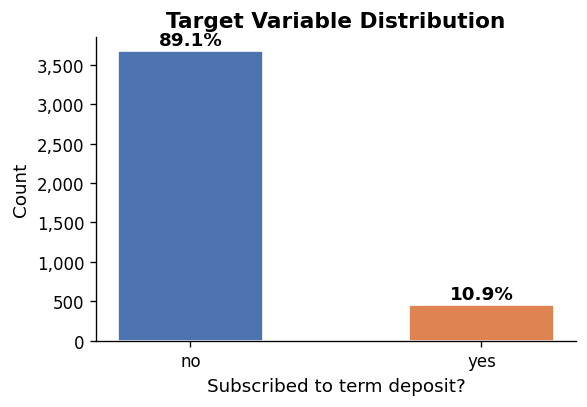

Ratio:89.1%  yes:10.9%
The dataset is significantly imbalanced (around 11% positive class).


In [10]:
target_counts = df['y'].value_counts()
target_pct    = df['y'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(target_counts.index, target_counts.values,
              color=PALETTE, edgecolor='white', width=0.5)
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Target Variable Distribution', fontweight='bold')
ax.set_xlabel('Subscribed to term deposit?')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()
print(f'Ratio:{target_pct["no"]:.1f}%  yes:{target_pct["yes"]:.1f}%')
print('The dataset is significantly imbalanced (around 11% positive class).')

In [12]:
explicit_missing = df.isnull().sum()
print('NaN counts:')
print(explicit_missing[explicit_missing > 0] if explicit_missing.sum() > 0 else '  None found.')

print('\nImplicit missing values:')
for col in df.select_dtypes(include='object').columns:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f'  {col:20s}: {n:4d}  ({100*n/len(df):.1f}%)')

print('\npdays value distribution (top 5):')
print(df['pdays'].value_counts().head())
print(f'  {(df["pdays"]==999).mean()*100:.1f}% of rows have pdays=999 (Dummy value representing never contacted).')

NaN counts:
  None found.

Implicit missing values:
  job                 :   39  (0.9%)
  marital             :   11  (0.3%)
  education           :  167  (4.1%)
  default             :  803  (19.5%)
  housing             :  105  (2.5%)
  loan                :  105  (2.5%)

pdays value distribution (top 5):
pdays
999    3959
3        52
6        42
4        14
7        10
Name: count, dtype: int64
  96.1% of rows have pdays=999 (Dummy value representing never contacted).


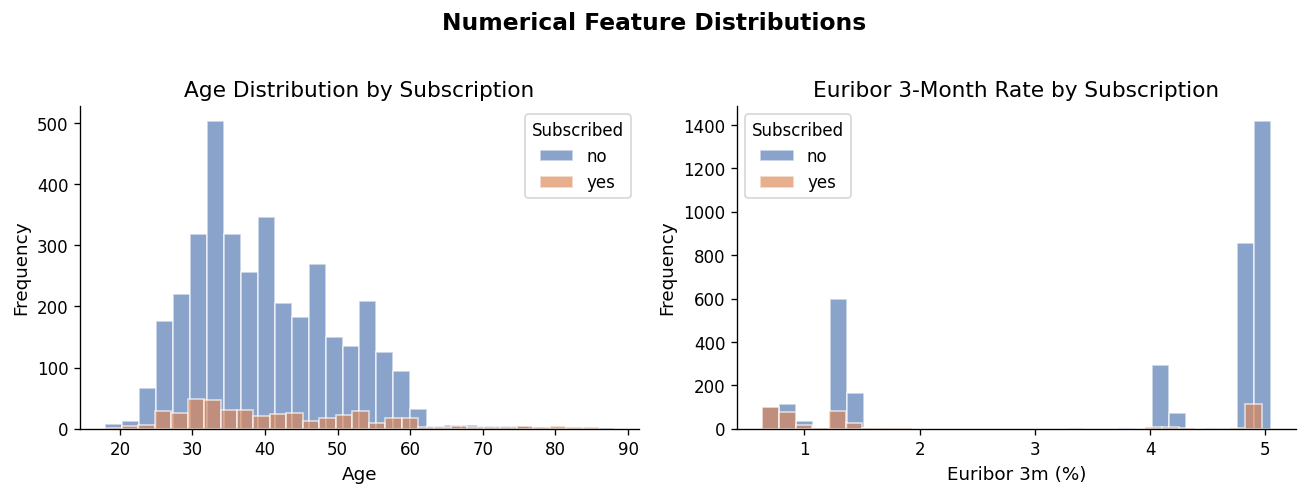

Subscribers cluster at lower Euribor rates: low interest rate environments
make term deposits more attractive.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
for label, color in zip(['no', 'yes'], PALETTE):
    df.loc[df['y']==label, 'age'].plot.hist(
        bins=30, alpha=0.65, color=color, ax=ax, label=label, edgecolor='white')
ax.set_title('Age Distribution by Subscription')
ax.set_xlabel('Age')
ax.legend(title='Subscribed')

ax = axes[1]
for label, color in zip(['no', 'yes'], PALETTE):
    df.loc[df['y']==label, 'euribor3m'].plot.hist(
        bins=30, alpha=0.65, color=color, ax=ax, label=label, edgecolor='white')
ax.set_title('Euribor 3-Month Rate by Subscription')
ax.set_xlabel('Euribor 3m (%)')
ax.legend(title='Subscribed')

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Subscribers cluster at lower Euribor rates: low interest rate environments')
print('make term deposits more attractive.')

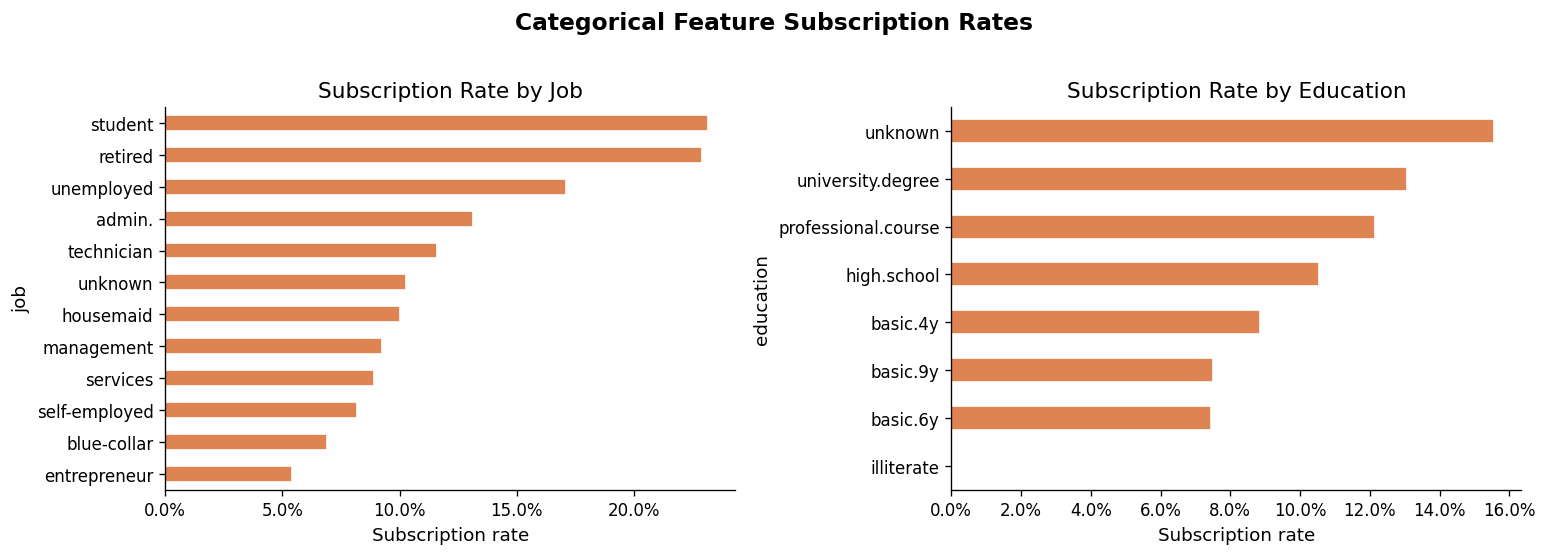

Students and retired clients show higher subscription rates.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, col in zip(axes, ['job', 'education']):
    ct = df.groupby(col)['y'].value_counts(normalize=True).unstack().fillna(0)
    ct['yes'].sort_values(ascending=True).plot.barh(
        ax=ax, color=PALETTE[1], edgecolor='white')
    ax.set_title(f'Subscription Rate by {col.capitalize()}')
    ax.set_xlabel('Subscription rate')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Categorical Feature Subscription Rates', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Students and retired clients show higher subscription rates.')

### Variable Requiring Special Consideration: **duration**

The **duration** feature records call duration in seconds. It is strongly correlated with the target but is not available at prediction time. Including it would constitute target leakage and will be removed.

---
## Step 3 - Managing Missing Values

| Type | Variables | Strategy | Justification |
|------|-----------|----------|---------------|
| Implicit (unknown) | job, marital, education, default, housing, loan | Keep as a separate category | unknown may carry predictive signal. Dropping rows would discard up to 20% of data. |
| Sentinel (999) | pdays | Create binary indicator + replace with 0 | 999 means never contacted, a qualitatively different state. |

Since we use unknown as a separate category rather than imputing, no fitted parameters are required here. The transformation is rule-based and safe to apply before splitting.

In [ ]:
df_clean = df.copy()

# 1. Remove target-leaking feature
df_clean = df_clean.drop(columns=['duration'])
print('Dropped duration (target leakage).')

# 2. Create binary indicator for pdays sentinel
df_clean['was_contacted_before'] = (df_clean['pdays'] != 999).astype(int)
df_clean['pdays'] = df_clean['pdays'].replace(999, 0)
print('Created was_contacted_before from pdays sentinel.')

# 3. Encode target variable
df_clean['y'] = (df_clean['y'] == 'yes').astype(int)
print('Encoded target: yes=1, no=0')

print(f'\nDataset shape after cleaning: {df_clean.shape}')

---
## Step 4 - Data Splitting

**Proportions:** 70% training / 15% validation / 15% test.

**Stratified splitting** is essential because the target is imbalanced (~11% positive). Without stratification, a random split could place very few positive examples in validation/test, making evaluation unreliable.

**Types of leakage from splitting too late:**

- Scaling leakage: scaler statistics estimated using test data
- Encoding leakage: encoder frequencies influenced by test categories
- Resampling leakage: synthetic samples generated near test points

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X = df_clean.drop(columns=['y'])
y = df_clean['y']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f'Train      : {X_train.shape[0]:4d} rows  (positive rate: {y_train.mean():.3f})')
print(f'Validation : {X_val.shape[0]:4d} rows  (positive rate: {y_val.mean():.3f})')
print(f'Test       : {X_test.shape[0]:4d} rows  (positive rate: {y_test.mean():.3f})')
print('\nClass ratios preserved across all splits.')

---
## Step 5 - Encoding Categorical Variables

| Variable | Type | Encoding | Justification |
|----------|------|----------|---------------|
| job, marital, contact, poutcome, month, day_of_week, default, housing, loan | Nominal | One-Hot (drop first) | No natural order. |
| education | Ordinal | Ordinal Encoding | Meaningful order: illiterate < basic.4y < basic.6y < basic.9y < high.school < professional.course < university.degree |

**Effect on Logistic Regression:**

- Each OHE coefficient represents the log-odds change for that category versus the reference.
- The model remains linear in the encoded space.
- Dimensionality increases but coefficients become interpretable per category.

**All encoders are fitted on the training set only.**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

ORDINAL_COL = 'education'
EDUCATION_ORDER = [
    ['unknown', 'illiterate', 'basic.4y', 'basic.6y',
     'basic.9y', 'high.school', 'professional.course', 'university.degree']
]

NOMINAL_COLS = ['job', 'marital', 'default', 'housing', 'loan',
                'contact', 'month', 'day_of_week', 'poutcome']

ord_enc = OrdinalEncoder(categories=EDUCATION_ORDER,
                         handle_unknown='use_encoded_value', unknown_value=-1)
ord_enc.fit(X_train[[ORDINAL_COL]])

def apply_ordinal(X_df):
    X_out = X_df.copy()
    X_out[[ORDINAL_COL]] = ord_enc.transform(X_df[[ORDINAL_COL]])
    return X_out

X_train = apply_ordinal(X_train)
X_val   = apply_ordinal(X_val)
X_test  = apply_ordinal(X_test)

X_train_enc = pd.get_dummies(X_train, columns=NOMINAL_COLS, drop_first=True, dtype=int)
TRAIN_COLS  = X_train_enc.columns.tolist()

def align_ohe(X_df, reference_cols):
    X_enc = pd.get_dummies(X_df, columns=NOMINAL_COLS, drop_first=True, dtype=int)
    return X_enc.reindex(columns=reference_cols, fill_value=0)

X_val_enc  = align_ohe(X_val,  TRAIN_COLS)
X_test_enc = align_ohe(X_test, TRAIN_COLS)

print(f'Columns before encoding: {X_train.shape[1]}')
print(f'Columns after encoding : {X_train_enc.shape[1]}')
print(f'Column sets consistent : {X_train_enc.columns.tolist() == X_val_enc.columns.tolist()}')

---
## Step 6 - Feature Scaling

**Why StandardScaler for Logistic Regression:**

1. **Gradient-based optimization:** Features on different scales create an elongated loss surface, slowing convergence.
2. **Coefficient comparability:** Without scaling, coefficient magnitude reflects feature scale, not importance.
3. **Regularization (L2):** Without scaling, large-range features are under-penalized and small-range features over-penalized.

Binary and one-hot encoded columns are already on the [0,1] scale and are excluded from scaling.

**The scaler is fitted on the training set only.**

In [ ]:
from sklearn.preprocessing import StandardScaler

SCALE_COLS = [c for c in X_train_enc.select_dtypes(include=np.number).columns
              if X_train_enc[c].nunique() > 2]

print(f'Columns to scale ({len(SCALE_COLS)}): {SCALE_COLS}')

scaler = StandardScaler()
scaler.fit(X_train_enc[SCALE_COLS])

def apply_scaling(X_df):
    X_out = X_df.copy()
    X_out[SCALE_COLS] = scaler.transform(X_df[SCALE_COLS])
    return X_out

X_train_scaled = apply_scaling(X_train_enc)
X_val_scaled   = apply_scaling(X_val_enc)
X_test_scaled  = apply_scaling(X_test_enc)

print('\nMean of scaled training features (should be ~0):')
print(X_train_scaled[SCALE_COLS].mean().round(5))
print('\nStd of scaled training features (should be ~1):')
print(X_train_scaled[SCALE_COLS].std().round(5))

---
## Step 7 - Feature Selection

All selection decisions use **training-set statistics only**. Computing variances or correlations on the full dataset incorporates test-set structure, a subtle form of leakage.

**Low-variance filter:** remove features with variance < 0.01 (constant or near-constant in >99% of samples).

**Correlation filter:** remove one feature from each pair with |r| > 0.85, choosing the feature with higher mean correlation to other features.

**Why this matters for Logistic Regression:** highly correlated features cause multicollinearity, making coefficient estimates unstable and inflating their variance.